# Complemento de calidad: faltantes semanticos en ARMD-AI

## Por que existe este notebook

El archivo `comparacion_nulos.csv` es util para ver `NaN` tecnicos, pero no cuenta categorias como `SIN_REGISTRO` o `SIN_REGLA`.

Eso puede confundir la interpretacion, porque una variable puede tener `0%` de nulos y aun asi tener mucha ausencia real de informacion.

Este notebook complementa el primer analisis y separa:

- `NaN` real
- faltante semantico
- cobertura real


## Regla importante

Este bloque no reemplaza el primer notebook. Lo complementa.

La idea es dejar mas clara la calidad real de las variables categoricas rellenadas durante la limpieza.


In [5]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Image, display
import pandas as pd

RUTA_PROYECTO = Path.cwd().resolve().parent
RUTA_PROCESADOS = RUTA_PROYECTO / "3.DATOS-PROCESADOS"
RUTA_GRAFICAS = RUTA_PROYECTO / "2.VISUALIZACION-DATOS" / "EXPOSICION"
RUTA_SCRIPT = RUTA_PROYECTO / "2.VISUALIZACION-DATOS" / "generar_reporte_faltantes_semanticos.py"

print(RUTA_PROCESADOS)
print(RUTA_GRAFICAS)
print(RUTA_SCRIPT)

D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS
D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\2.VISUALIZACION-DATOS\EXPOSICION
D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\2.VISUALIZACION-DATOS\generar_reporte_faltantes_semanticos.py


## Generar este reporte desde notebook

La siguiente celda ejecuta el proceso real de generacion y deja los artefactos listos desde Jupyter Lab.

Esto genera:

- `3.DATOS-PROCESADOS/reporte_faltantes_semanticos.csv`
- `2.VISUALIZACION-DATOS/EXPOSICION/expo_11_faltantes_semanticos.png`


In [6]:
resultado = subprocess.run(
    [sys.executable, str(RUTA_SCRIPT)],
    cwd=RUTA_SCRIPT.parent,
    capture_output=True,
    text=True,
    check=True,
)
print(resultado.stdout)
if resultado.stderr.strip():
    print('STDERR:')
    print(resultado.stderr)

Reporte generado: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\3.DATOS-PROCESADOS\reporte_faltantes_semanticos.csv
Grafica generada: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\2.VISUALIZACION-DATOS\EXPOSICION\expo_11_faltantes_semanticos.png



In [7]:
df_reporte = pd.read_csv(RUTA_PROCESADOS / "reporte_faltantes_semanticos.csv")
display(df_reporte)

,variable,porcentaje_na_real,porcentaje_faltante_semantico,porcentaje_cobertura_real
0,prior_organism,0.00,100.00,0.00
1,implied_susceptibility,0.00,100.00,0.00
2,Rule,0.00,100.00,0.00
3,prior_infecting_organism_days_to_culture,100.00,0.00,0.00
4,nursing_home_visit_culture,99.26,0.00,0.74
5,median_wbc,68.42,0.00,31.58
6,median_cr,68.36,0.00,31.64
7,procedure_name,0.00,65.53,34.47
8,antibiotic_class,0.00,29.77,70.23
9,time_to_culturetime,29.77,0.00,70.23


## Grafica principal

### Que muestra
- diferencia entre `NaN` reales y faltantes semanticos
- cuales variables parecen limpias tecnicamente, pero siguen vacias en terminos informativos

### Por que importa
- `procedure_name` puede verse con `0%` de nulos tecnicos, pero sigue teniendo mucho `SIN_REGISTRO`
- `implied_susceptibility`, `Rule` y `prior_organism` pueden tener `0%` de nulos y aun asi no aportar senal real

### Mensaje para la exposicion
- no basta con decir que una variable ya no tiene `NaN`
- tambien hay que mirar si trae informacion real o solo etiquetas que representan ausencia de dato


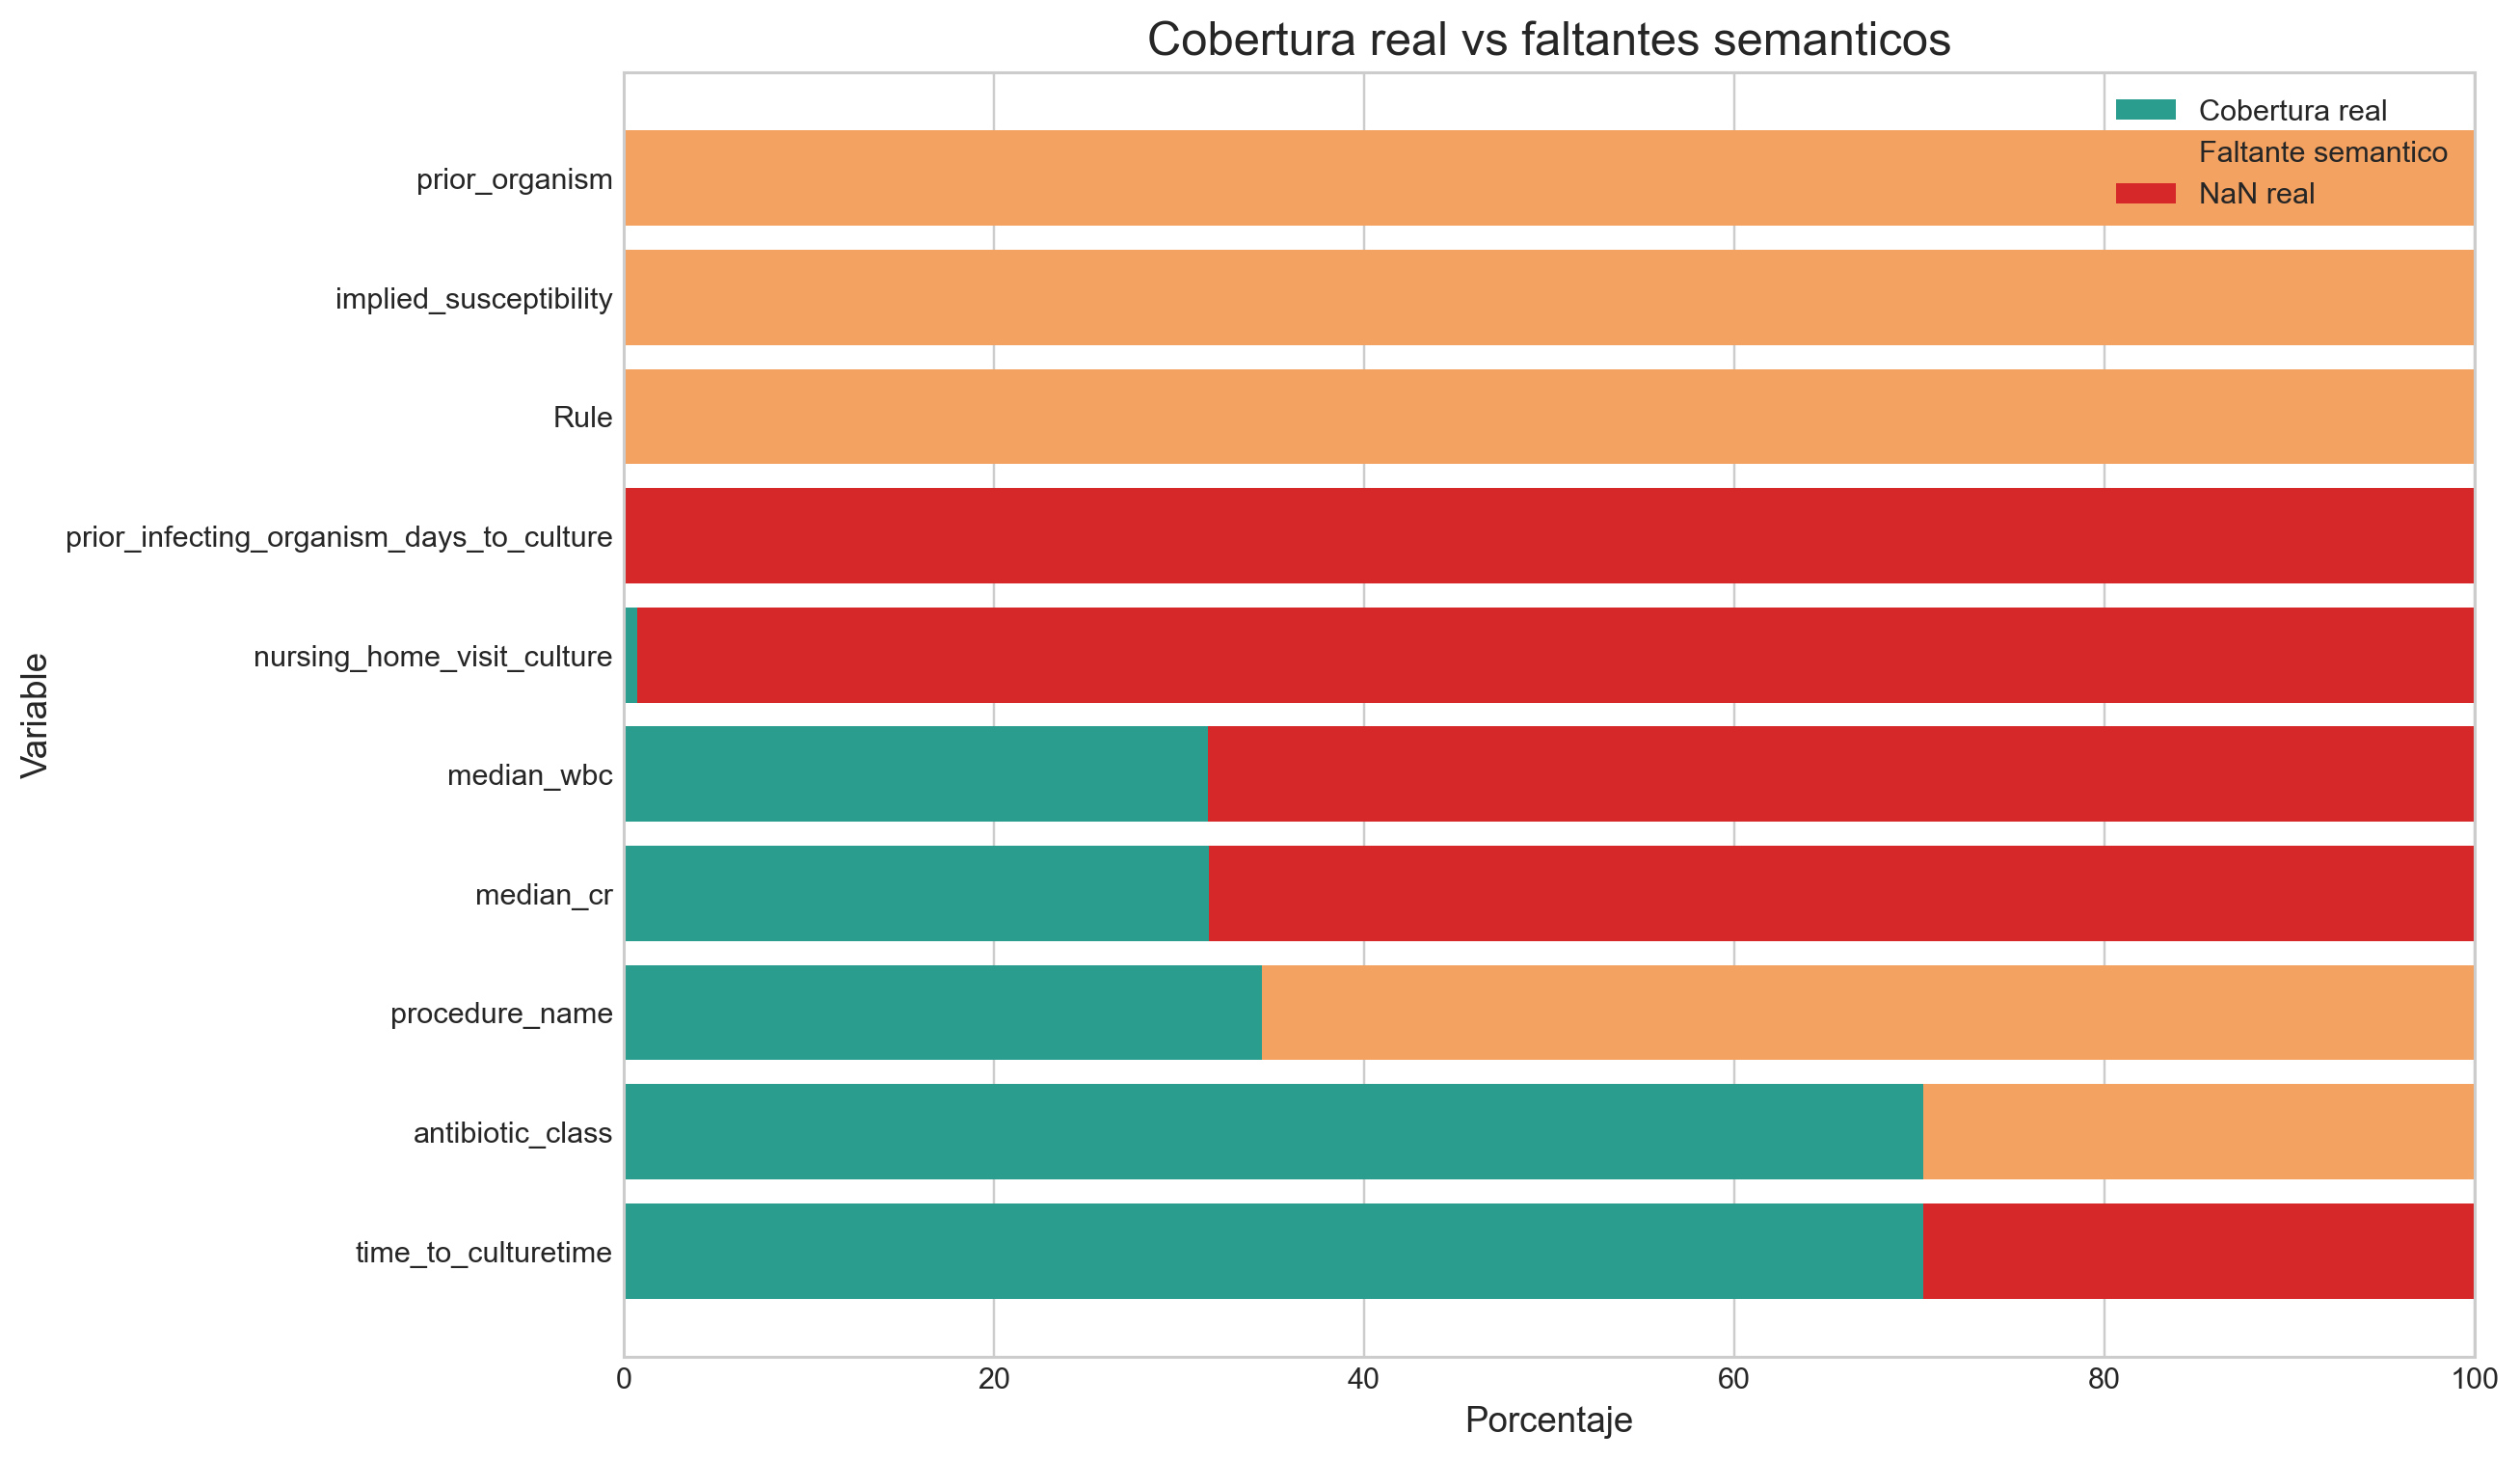

In [8]:
display(Image(filename=str(RUTA_GRAFICAS / "expo_11_faltantes_semanticos.png")))


## Ejemplos concretos para defender oralmente

- `procedure_name`: no tiene `NaN` final, pero gran parte de sus registros quedaron como `SIN_REGISTRO`, asi que su cobertura real sigue siendo limitada
- `antibiotic_class`: tecnicamente no tiene `NaN` despues de la limpieza, pero una parte importante de la cohorte no trae antecedente de exposicion antibiotica previa
- `prior_organism`, `Rule` e `implied_susceptibility`: aunque no tengan `NaN`, quedaron sin contenido diferencial util en esta iteracion

Esto explica por que no se debe confundir limpieza tecnica con informacion clinica util.
